<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/labs/04_poisson_models_in_class_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Distributions related to Count data




### glm package (called as family in glm)
For count data glm package has two options

1. Poisson distribution
2. Negative binomial distribution

In [5]:
install.packages('AER')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘forecast’, ‘doBy’, ‘reformulas’, ‘pbkrtest’, ‘lme4’, ‘car’




In [9]:
library(stats)
library(MASS)
library(dplyr)
library(ggplot2)
library(GlmSimulatoR)
#install.packages("AER", type = "binary")

In [29]:
install.packages('GlmSimulatoR')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [10]:
set.seed(1) ## setting a random seed number for same results for every run;

## Poisson distribution

In [11]:
#lambda = 1
poisson <- rpois(n = 10000, lambda = 1) ## this function helps generate random data with specific poisson distrbution
#print(poisson)
poissonDF <- as.data.frame(x=poisson)

In [ ]:
#poissonDF

#### plotting the data generated

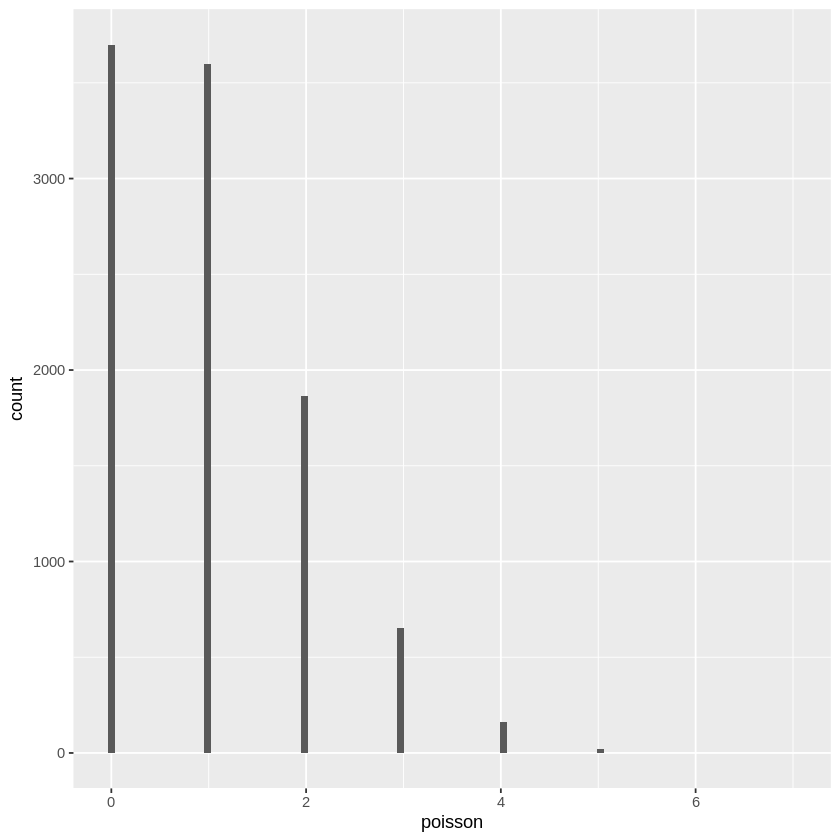

In [12]:
ggplot(poissonDF, aes(x=poisson)) +
  geom_histogram(bins = 100)

#### If lambda is near 1, the Poisson family is right skewed. As lambda increases, the Poisson family becomes more symmetrical.

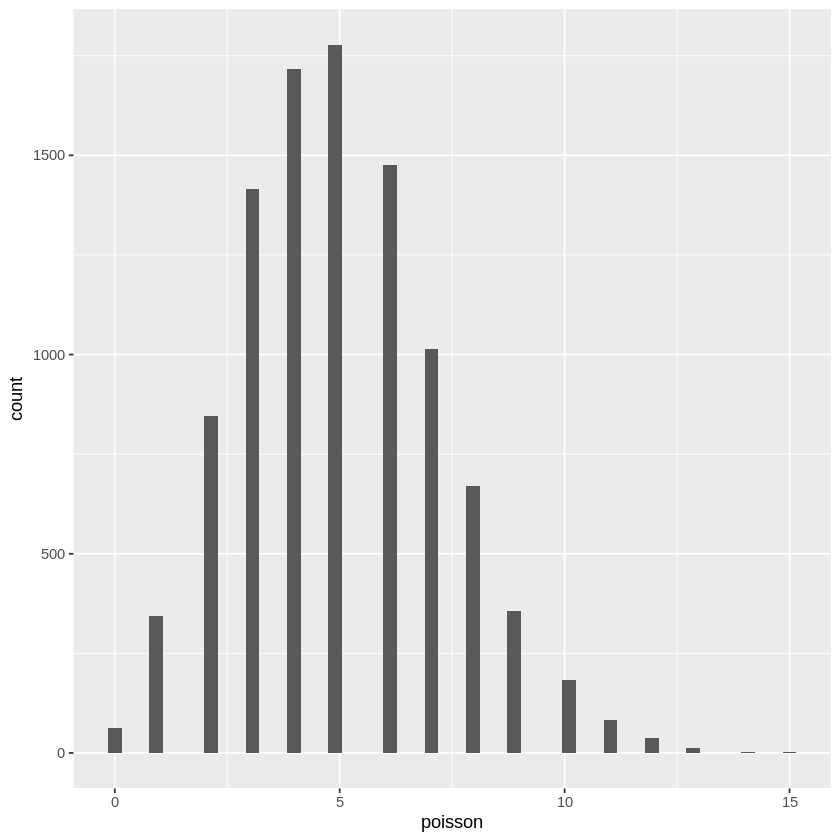

In [13]:
#lambda = 5
poisson <- rpois(n = 10000, lambda = 5)
poissonDF <- as.data.frame(x=poisson)

ggplot(poissonDF, aes(x=poisson)) +
  geom_histogram(bins = 50)

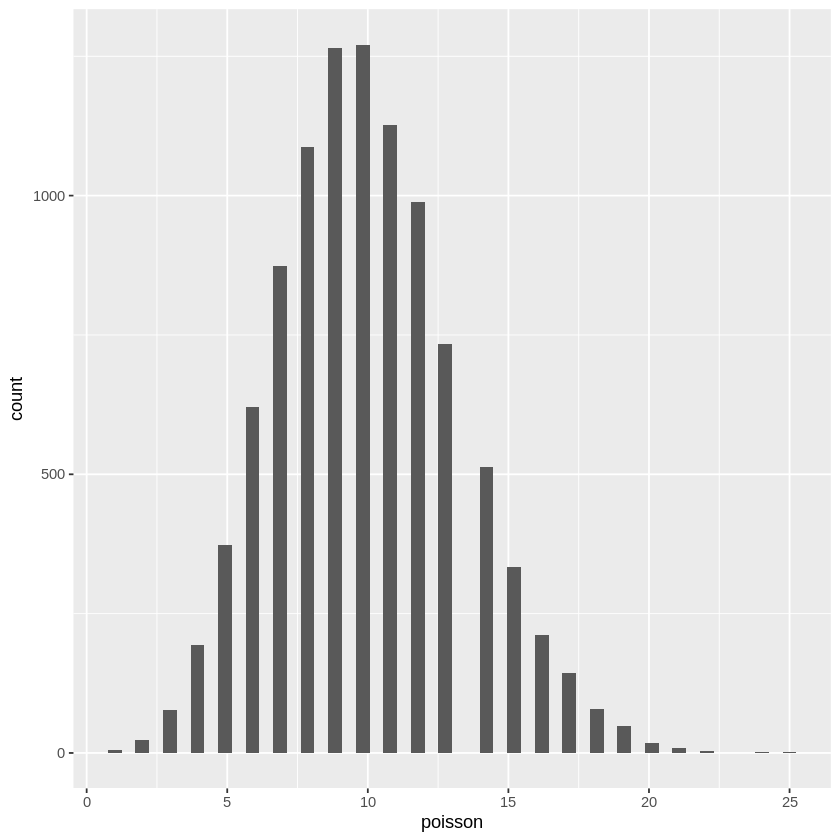

In [14]:
#lambda = 10
poisson <- rpois(n = 10000, lambda = 10)
poissonDF <- as.data.frame(x=poisson)

ggplot(poissonDF, aes(x=poisson)) +
  geom_histogram(bins = 50)

### Poisson mean variance relationship

One important characteristic of the Poisson family is μ equals σ2. We see the sample statistics are nearly equal for different values of lambda.

In [15]:
#lambda = 1
poisson <- rpois(n = 10000, lambda = 1)
mean(poisson)

[1] 1.0014

In [16]:
var(poisson)

[1] 1.003098

In [17]:
#lambda = 5
poisson <- rpois(n = 10000, lambda = 5)
mean(poisson)

[1] 5.055

In [18]:
var(poisson)


[1] 5.173492

## Negative Binomial

The main difference between Poisson and the negative binomial is the extra parameter. The mean variance relationship is σ$^2$ equals μ+$μ^{2}$/θ for the negative binomial. Through θ many relationships are possible.

When the response variable is a count, but μ does not equal $μ^{2}$, the Poisson distribution is not applicable. Over dispersion can be detected by dividing the residual deviance by the degrees of freedom. If this quotient is much greater than one, the negative binomial distribution should be used. There is no hard cut off of “much larger than one”, but a rule of thumb is 1.10 or greater is considered large.

When θ is large, μ+$μ^{2}$/θ is roughly equal to μ . Therefore the negative binomial will be similar to Poisson distribution.

[1] 1.0055

[1] 1.00617

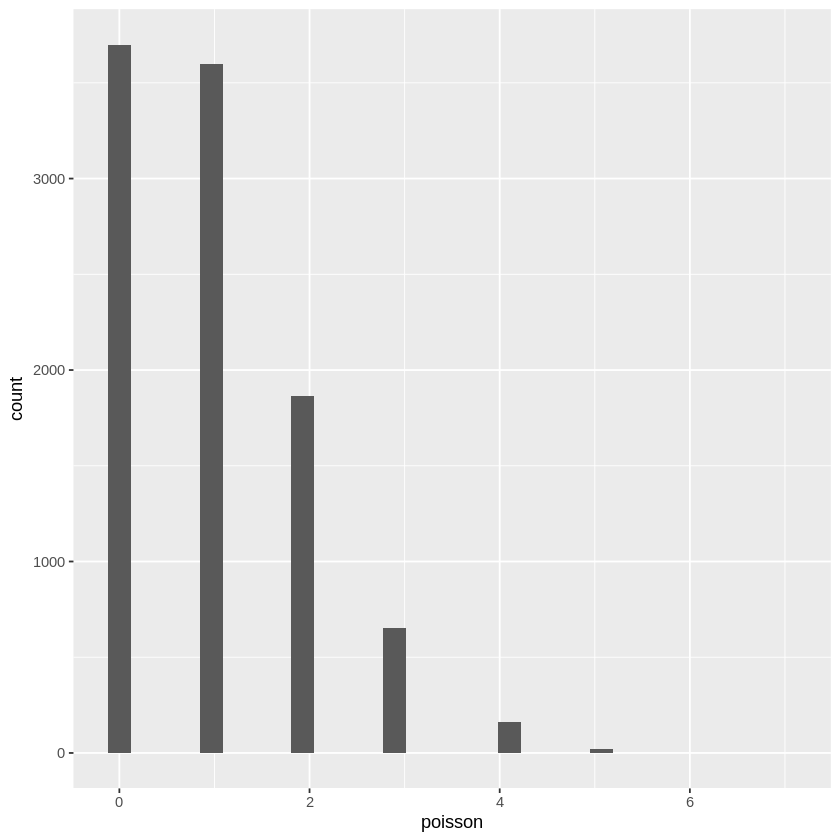

In [19]:
set.seed(1)

poisson <- rpois(n = 10000, lambda = 1)
poissonDF <- as.data.frame(x=poisson)

ggplot(poissonDF, aes(x=poisson)) +
  geom_histogram(bins = 30)
mean(poisson)
var(poisson)

[1] 1.007

[1] 1.446496

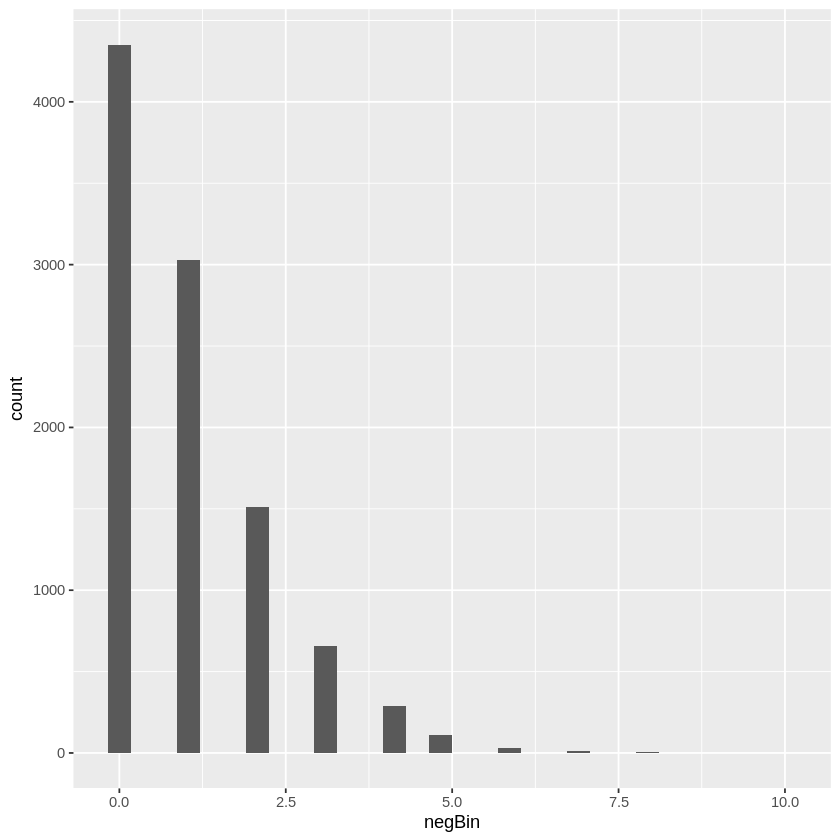

In [20]:
negBin <- rnegbin(n = 10000, mu = 1, theta = 2)
negBinDF <- as.data.frame(x=negBin)

ggplot(negBinDF, aes(x=negBin)) +
  geom_histogram(bins = 30)
mean(negBin)
var(negBin)

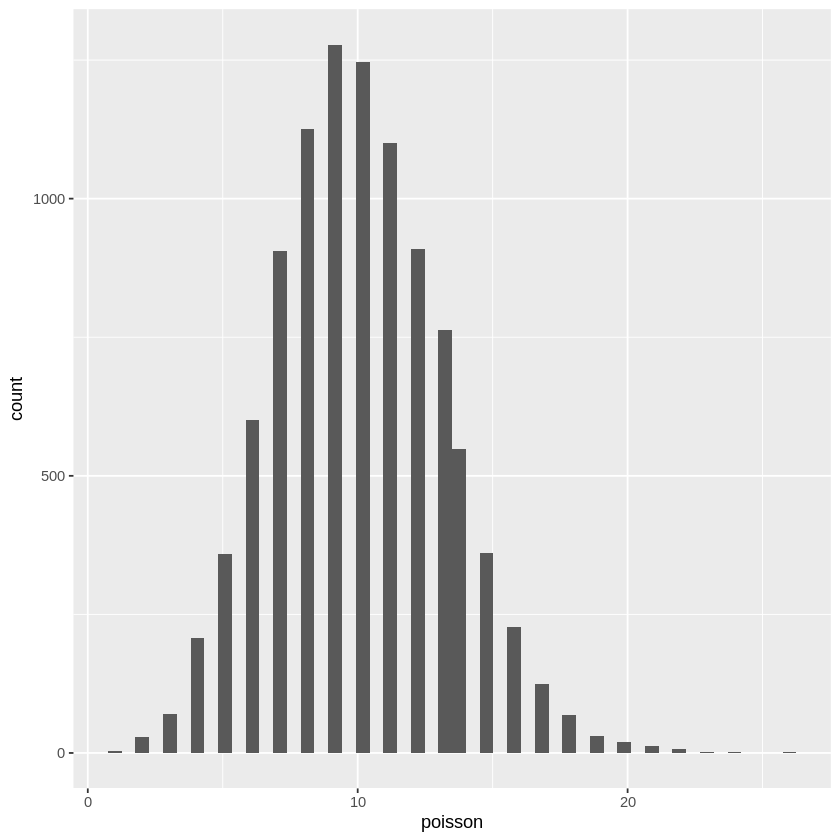

In [21]:
set.seed(1)

poisson <- rpois(n = 10000, lambda = 10)
poissonDF <- as.data.frame(x=poisson)

ggplot(poissonDF, aes(x=poisson)) +
  geom_histogram(bins = 50)

In [ ]:
#poisson

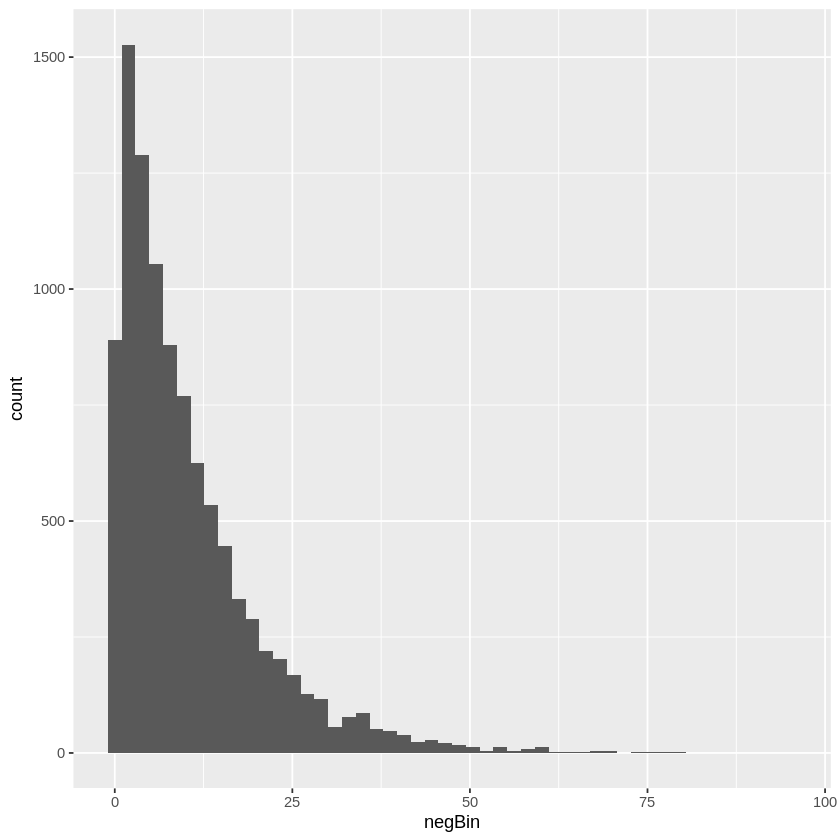

In [22]:
negBin <- rnegbin(n = 10000, mu = 10, theta = 1)
negBinDF <- as.data.frame(x=negBin)

ggplot(negBinDF, aes(x=negBin)) +
  geom_histogram(bins = 50)

In [ ]:
#binomial

## GLM Negative Binomial

Lets create data where the flexibility of the negative binomial is needed and compare the Poisson estimates to the negative binomial estimates.

In [23]:
#simdata

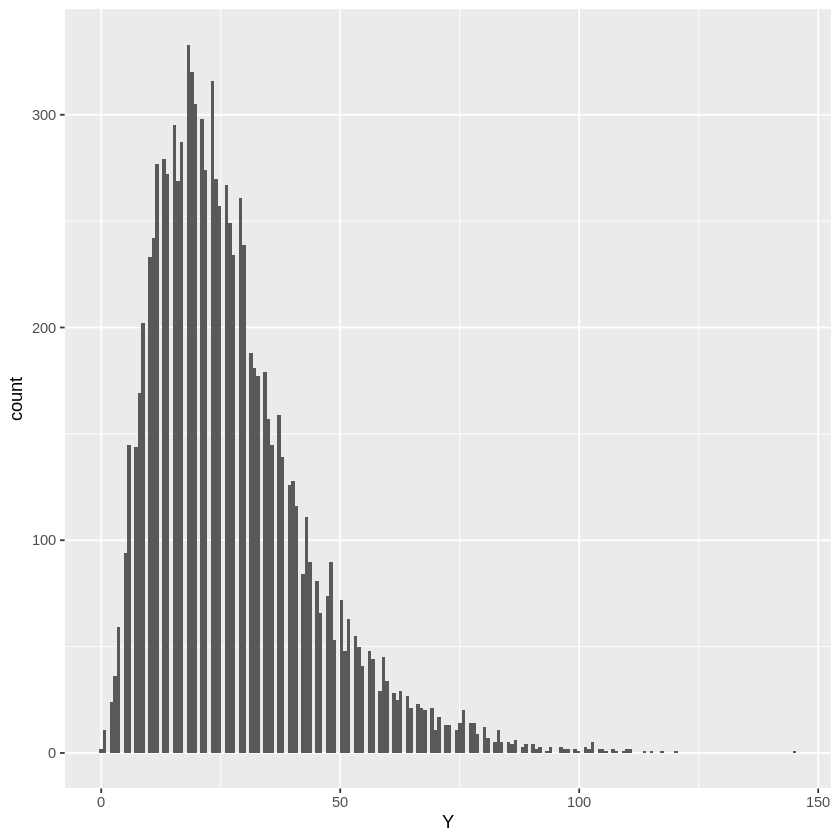

In [24]:
set.seed(1)
simdata <- simulate_negative_binomial(N = 10000, weights = c(.5, 1), ancillary = 5) #ancillary is theta.

#Response looks like a negative binomial distribution.
ggplot(simdata, aes(x=Y)) +
  geom_histogram(bins = 200)

In [ ]:
#fake data

In [25]:
head(simdata)

Y,X1,X2
<int>,<dbl>,<dbl>
8,1.265509,1.064712
16,1.372124,1.676612
21,1.572853,1.735372
6,1.908208,1.111300
14,1.201682,1.046655
10,1.898390,1.130910


In [26]:
glmPoisson <- glm(Y ~ X1 + X2, data = simdata, family = poisson(link = "log"))
glmNB <- glm.nb(Y ~ X1 + X2, data = simdata, link = "log")


summary(glmPoisson)


Call:
glm(formula = Y ~ X1 + X2, family = poisson(link = "log"), data = simdata)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) 0.995434   0.014925   66.70   <2e-16 ***
X1          0.511899   0.006608   77.47   <2e-16 ***
X2          0.995539   0.006797  146.46   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 91470  on 9999  degrees of freedom
Residual deviance: 63327  on 9997  degrees of freedom
AIC: 113055

Number of Fisher Scoring iterations: 4


In [27]:
summary(glmNB)


Call:
glm.nb(formula = Y ~ X1 + X2, data = simdata, link = "log", init.theta = 4.967762132)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  0.98915    0.03658   27.04   <2e-16 ***
X1           0.51132    0.01689   30.28   <2e-16 ***
X2           1.00018    0.01707   58.60   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(4.9678) family taken to be 1)

    Null deviance: 14739  on 9999  degrees of freedom
Residual deviance: 10364  on 9997  degrees of freedom
AIC: 77883

Number of Fisher Scoring iterations: 1


              Theta:  4.9678 
          Std. Err.:  0.0835 

 2 x log-likelihood:  -77874.7800 

In [ ]:
# key take away beta estaimtes are closer to each other and not changing a lot; the standard error does change however; interpreatations dont change

residual deviance = 63327 divided by std error

The estimated slopes are very similar. However, the standard errors are not. The fact μ does not equal $μ^{2}$ has caused a major under estimation of standard errors for the Poisson GLM. For Poisson models, it is important to look at residual deviance divided by the degrees of freedom. When this quotient is larger than 1, the negative binomial should be considered. If closer to 1, Poisson may be ok. In the above the quotient was 6.33 (63327 / 9997) for the Poisson glm. For these data, the negative binomial model is more appropriate.

# Lung Cancer Example

### Example: The number of lung cancer cases in four Danish cities
* from 1968 to 1971 are recorded.
* There are 24 observations on each of 4 variables:  
* Cases: the number of lung cancer cases  
* Pop: the population of each age group in each city  
* Age: the categorical age group; one of 40 - 54, 55 - 59, 60 - 64, 65 - 74 or > 74
* City: the city; one of Fredericia, Horsens, Kolding, or Vejle  

#### I How does the expected number of lung cancer counts vary by age?


In [30]:
install.packages('ISwR')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [31]:
library(ISwR)
data = eba1977
head(data)

,city,age,pop,cases
,<fct>,<fct>,<int>,<int>
1,Fredericia,40-54,3059,11
2,Horsens,40-54,2879,13
3,Kolding,40-54,3142,4
4,Vejle,40-54,2520,5
5,Fredericia,55-59,800,11
6,Horsens,55-59,1083,6


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


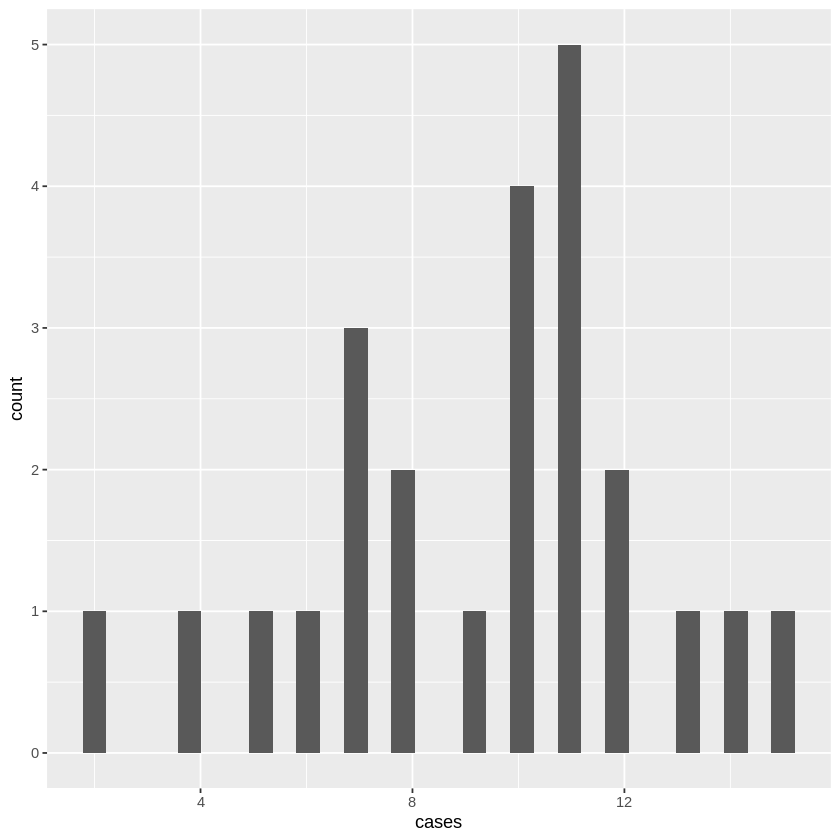

In [32]:
ggplot(data, aes(x=cases)) +
  geom_histogram()

how to check if this is poisson? --> check the mean and variance

In [33]:
mean(data$cases)

[1] 9.333333

In [34]:
var(data$cases)

[1] 9.971014

#### Number of Lung Cancer cases by age group per city

In [35]:
xtabs(cases ~ age + city, data=data)

       city
age     Fredericia Horsens Kolding Vejle
  40-54         11      13       4     5
  55-59         11       6       8     7
  60-64         11      15       7    10
  65-69         10      10      11    14
  70-74         11      12       9     8
  75+           10       2      12     7

#### Population of the four cities by age group

In [36]:
xtabs(pop ~ age + city, data=data)

       city
age     Fredericia Horsens Kolding Vejle
  40-54       3059    2879    3142  2520
  55-59        800    1083    1050   878
  60-64        710     923     895   839
  65-69        581     834     702   631
  70-74        509     634     535   539
  75+          605     782     659   619

### How does the expected number of lung cancer counts vary by age?

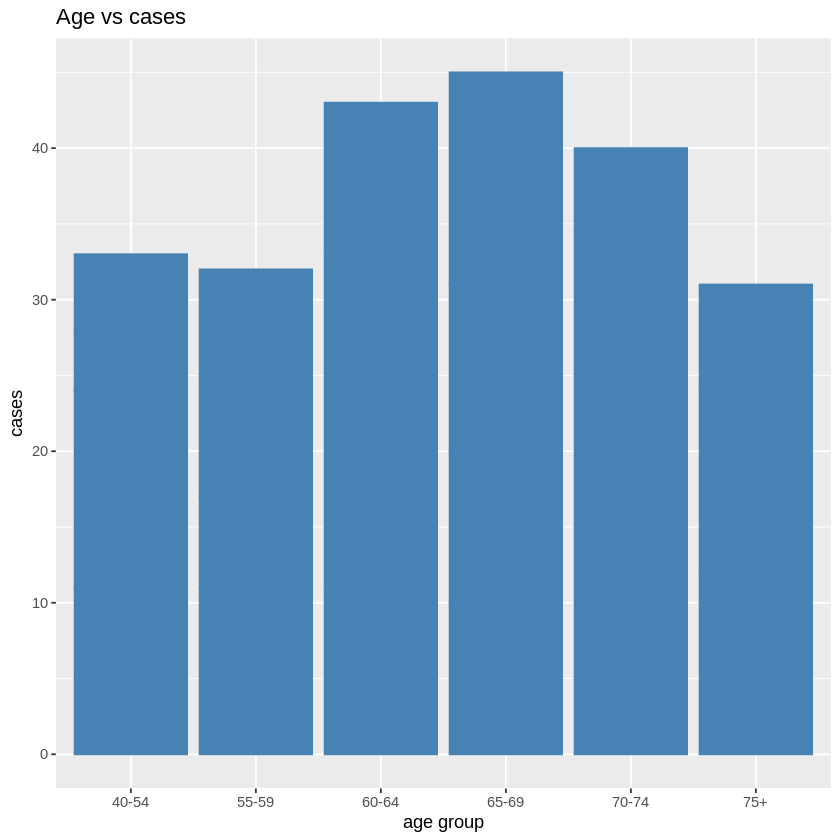

In [37]:
p = ggplot(data, aes(x = age, y = cases)) +
geom_bar(stat="identity", color = 'steelblue', fill = 'steelblue')+
xlab('age group')+ ylab('cases')+
labs(title = "Age vs cases")
p

do expect to see increase in +75? it shows decrease, so what do we think is happening?

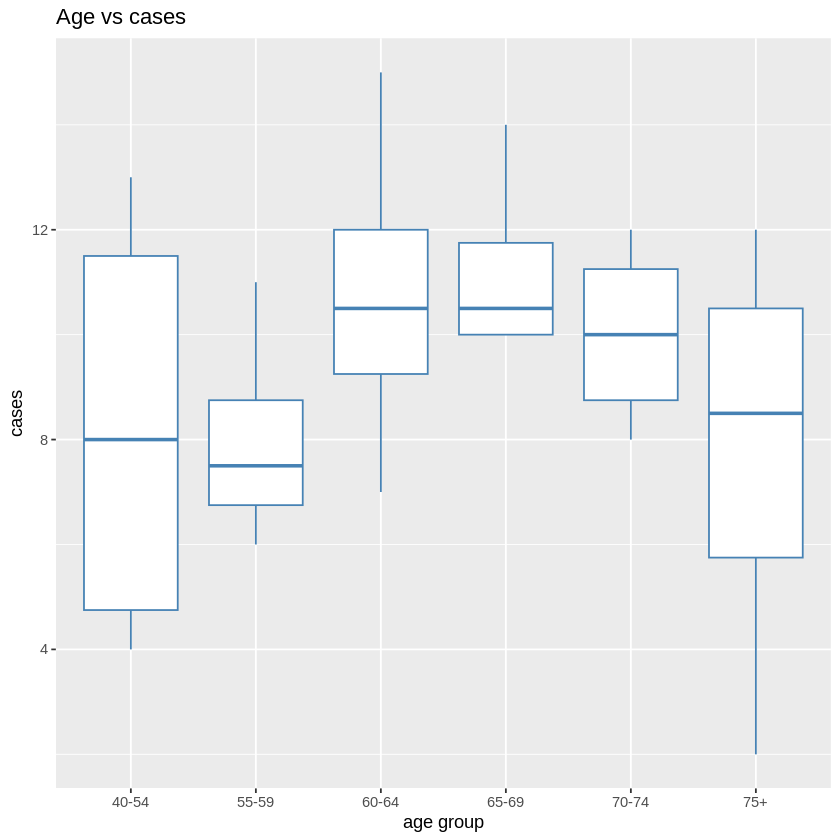

In [38]:
p = ggplot(data, aes(x = age, y = cases)) +
geom_boxplot(color = 'steelblue')+
xlab('age group')+ ylab('cases')+
labs(title = "Age vs cases")
p

always check structure (below)

In [39]:
str(data)

'data.frame':	24 obs. of  4 variables:
 $ city : Factor w/ 4 levels "Fredericia","Horsens",..: 1 2 3 4 1 2 3 4 1 2 ...
 $ age  : Factor w/ 6 levels "40-54","55-59",..: 1 1 1 1 2 2 2 2 3 3 ...
 $ pop  : int  3059 2879 3142 2520 800 1083 1050 878 710 923 ...
 $ cases: int  11 13 4 5 11 6 8 7 11 15 ...


In [40]:
levels(data$age)

[1] "40-54" "55-59" "60-64" "65-69" "70-74" "75+"

##### change "age" to factor if your R is not reading it as factor; will solve a lot of issues

In [41]:
data$age = factor(data$age)

default link is loglink

In [42]:
model = glm(cases ~ age, data=data, family="poisson")
summary(model)


Call:
glm(formula = cases ~ age, family = "poisson", data = data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  2.11021    0.17408  12.122   <2e-16 ***
age55-59    -0.03077    0.24810  -0.124    0.901    
age60-64     0.26469    0.23143   1.144    0.253    
age65-69     0.31015    0.22918   1.353    0.176    
age70-74     0.19237    0.23516   0.818    0.413    
age75+      -0.06252    0.25012  -0.250    0.803    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 27.704  on 23  degrees of freedom
Residual deviance: 22.756  on 18  degrees of freedom
AIC: 131.14

Number of Fisher Scoring iterations: 4


log($μ_{i}$)= 2.11 - 0.03 $X_{A55, i}$ + 0.265$X_{A60, i}$ + 0.31$X_{A65, i}$+ 0.192$X_{A70,i}$ - 0.0625$X_{75,i}$

-- beta0=2.11

#### Is the relationship of lung cancer cases with age statistically signficant?

$H_{0}$ : $B_{1}$ $=$ $B_{2}$ $=$ $B_{3}$ $=$ $B_{4}$ $=$ $B_{5}$ $= 0$, vs.  
$H_{a}$: at lease one of the $B_{i}$s is not 0

In [44]:
print(drop1(model, test = 'Chisq'))

Single term deletions

Model:
cases ~ age
       Df Deviance    AIC    LRT Pr(>Chi)
<none>      22.756 131.14                
age     5   27.704 126.09 4.9478   0.4223


In [ ]:
?drop1

### Go to slides for interpretation

$deviance(reduced) = 22.756$  
$deviance(full) = 27.756$  
$LRT statistic$      
$G^2 = 27.704-22.756 = 4.9478$   
$df = 23-18 = 5$

$Under,  H_{0}$, $G^{2}~~ X^{2}_{df = 5}, p = 0.42$

### do not reject H0. The relationship with age is not statistically signficant

## Offsets and Poisson Rate

### Go to slides

#### Accounting for population size, the relationship of lung cancer cases and age is:

In [ ]:
head(data)

In [ ]:
?glm

In [45]:
log(data$pop/2500)

[1]  0.20179733  0.14115228  0.22856881  0.00796817 -1.13943428 -0.83655576
 [7] -0.86750057 -1.04639942 -1.25878104 -0.99641678 -1.02722229 -1.09183530
[13] -1.45929525 -1.09781261 -1.27011261 -1.37674015 -1.59159799 -1.37199706
[19] -1.54177926 -1.53433044 -1.41881755 -1.16219127 -1.33332248 -1.39594074

In [46]:
model2 = glm(cases ~ age + offset(log(pop/2500)), data=data, family="poisson")
summary(model2)


Call:
glm(formula = cases ~ age + offset(log(pop/2500)), family = "poisson", 
    data = data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   1.9618     0.1741  11.270  < 2e-16 ***
age55-59      1.0823     0.2481   4.363 1.29e-05 ***
age60-64      1.5017     0.2314   6.489 8.66e-11 ***
age65-69      1.7503     0.2292   7.637 2.22e-14 ***
age70-74      1.8472     0.2352   7.855 4.00e-15 ***
age75+        1.4083     0.2501   5.630 1.80e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 129.908  on 23  degrees of freedom
Residual deviance:  28.307  on 18  degrees of freedom
AIC: 136.69

Number of Fisher Scoring iterations: 5


Among individuals aged 40-54, the estimated rate of lung cancer per 10,000 person-years is  
$e^B0 = e^{1.9618} = 7.112$,  
after the city population size is taken into account.

Among individuals aged 55-59, the estimated rate of lung cancer per 10,000 person-years is  
$e^{B0+B1} = e^{1.9618+1.0823} = 20.99$,  
after the city population size is taken into account.  

$e^{B1} = e^{1.0823} = 2.95$   
is the relative rate of cancer cases per 10,000 person-years comparing the age group 55-59 to baseline age group 40-54.

In [47]:
20.99/7.112

[1] 2.95135

In [48]:
exp(confint(model2))

Waiting for profiling to be done...



,2.5 %,97.5 %
(Intercept),4.953216,9.821960
age55-59,1.809509,4.808601
age60-64,2.859539,7.111934
age65-69,3.685433,9.084775
age70-74,4.005487,10.110915
age75+,2.495075,6.684026


## Adjusting for other covariates

want to see if theres an interaction bw city and age (below)

In [49]:
mod1 = glm(cases~offset(log(pop/2500)), data=data, family="poisson")
mod2 = glm(cases~offset(log(pop/2500)) + age, data=data, family="poisson")
mod3 = glm(cases~offset(log(pop/2500)) +age + city, data=data,family="poisson")
mod4 = glm(cases~offset(log(pop/2500)) + age * city, data=data, family="poisson") #Saturated model


In [50]:
print(anova(mod1,mod2,mod3,mod4, test="Chisq"))

Analysis of Deviance Table

Model 1: cases ~ offset(log(pop/2500))
Model 2: cases ~ offset(log(pop/2500)) + age
Model 3: cases ~ offset(log(pop/2500)) + age + city
Model 4: cases ~ offset(log(pop/2500)) + age * city
  Resid. Df Resid. Dev Df Deviance Pr(>Chi)    
1        23    129.908                         
2        18     28.307  5  101.601  < 2e-16 ***
3        15     23.447  3    4.859  0.18241    
4         0      0.000 15   23.447  0.07509 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [ ]:
choose model 2. explore what model looks like (below)

In [51]:
summary(mod3)


Call:
glm(formula = cases ~ offset(log(pop/2500)) + age + city, family = "poisson", 
    data = data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   2.1920     0.2003  10.946  < 2e-16 ***
age55-59      1.1010     0.2483   4.434 9.23e-06 ***
age60-64      1.5186     0.2316   6.556 5.53e-11 ***
age65-69      1.7677     0.2294   7.704 1.31e-14 ***
age70-74      1.8569     0.2353   7.891 3.00e-15 ***
age75+        1.4197     0.2503   5.672 1.41e-08 ***
cityHorsens  -0.3301     0.1815  -1.818   0.0690 .  
cityKolding  -0.3715     0.1878  -1.978   0.0479 *  
cityVejle    -0.2723     0.1879  -1.450   0.1472    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 129.908  on 23  degrees of freedom
Residual deviance:  23.447  on 15  degrees of freedom
AIC: 137.84

Number of Fisher Scoring iterations: 5


#### There is not a clear effect of City.

Model2 compared to Model3 shows lack of statistical signifcance: the City effect doesn't have to be considered in the model containing age with population offset, without a big loss of goodness of fit.

### Overdispersion

In [52]:
summary(model2)


Call:
glm(formula = cases ~ age + offset(log(pop/2500)), family = "poisson", 
    data = data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   1.9618     0.1741  11.270  < 2e-16 ***
age55-59      1.0823     0.2481   4.363 1.29e-05 ***
age60-64      1.5017     0.2314   6.489 8.66e-11 ***
age65-69      1.7503     0.2292   7.637 2.22e-14 ***
age70-74      1.8472     0.2352   7.855 4.00e-15 ***
age75+        1.4083     0.2501   5.630 1.80e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 129.908  on 23  degrees of freedom
Residual deviance:  28.307  on 18  degrees of freedom
AIC: 136.69

Number of Fisher Scoring iterations: 5


In [54]:
install.packages("AER")
library(AER)
dispersiontest(model2, alternative = "two.sided")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




	Dispersion test

data:  model2
z = 0.22584, p-value = 0.8213
alternative hypothesis: true dispersion is not equal to 1
sample estimates:
dispersion 
  1.066304 


### Here, disersion paremeter is essentially 1, no overdispersion.

Things to do when overdispersion is present

1. estimate the dispersion parameter from the model

In [55]:
sum(resid(model2, type="pearson")^2)/df.residual(model2)

[1] 1.447135

2. Estimate dispersion parameter from the model using quasi-likelihood. This requires you to refit the model:

In [56]:
model3 = glm(cases ~ age + offset(log(pop/2500)), data=data, family = quasipoisson(link=log))

In [60]:
summary(model3)$dispersion

[1] 1.447135

In [57]:
summary(model3)$dispersion

[1] 1.447135

### Correcting for dispersion

In [58]:
summary(model2)


Call:
glm(formula = cases ~ age + offset(log(pop/2500)), family = "poisson", 
    data = data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   1.9618     0.1741  11.270  < 2e-16 ***
age55-59      1.0823     0.2481   4.363 1.29e-05 ***
age60-64      1.5017     0.2314   6.489 8.66e-11 ***
age65-69      1.7503     0.2292   7.637 2.22e-14 ***
age70-74      1.8472     0.2352   7.855 4.00e-15 ***
age75+        1.4083     0.2501   5.630 1.80e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 129.908  on 23  degrees of freedom
Residual deviance:  28.307  on 18  degrees of freedom
AIC: 136.69

Number of Fisher Scoring iterations: 5


In [59]:
summary(model2, dispersion=1.447135)


Call:
glm(formula = cases ~ age + offset(log(pop/2500)), family = "poisson", 
    data = data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   1.9618     0.2094   9.368  < 2e-16 ***
age55-59      1.0823     0.2985   3.626 0.000287 ***
age60-64      1.5017     0.2784   5.394 6.89e-08 ***
age65-69      1.7503     0.2757   6.348 2.17e-10 ***
age70-74      1.8472     0.2829   6.530 6.59e-11 ***
age75+        1.4083     0.3009   4.680 2.86e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1.447135)

    Null deviance: 129.908  on 23  degrees of freedom
Residual deviance:  28.307  on 18  degrees of freedom
AIC: 136.69

Number of Fisher Scoring iterations: 5


get better estiamte of std errors when correcting for dispersion

## OR fit Negative Binomial Regression

In [61]:
model4 = glm(cases ~ age + offset(log(pop/2500)), data=data, family=negative.binomial(theta=1,link=log))
summary(model4)


Call:
glm(formula = cases ~ age + offset(log(pop/2500)), family = negative.binomial(theta = 1, 
    link = log), data = data)

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   1.9612     0.2000   9.806 1.21e-08 ***
age55-59      1.1166     0.2829   3.947 0.000944 ***
age60-64      1.5093     0.2810   5.371 4.19e-05 ***
age65-69      1.7727     0.2807   6.315 5.95e-06 ***
age70-74      1.8482     0.2815   6.566 3.61e-06 ***
age75+        1.4483     0.2830   5.117 7.21e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(1) family taken to be 0.142581)

    Null deviance: 9.9147  on 23  degrees of freedom
Residual deviance: 3.2980  on 18  degrees of freedom
AIC: 169.78

Number of Fisher Scoring iterations: 4


In [62]:
mean(data$cases)

[1] 9.333333

In [63]:
var(data$cases)

[1] 9.971014